# **Kurdistan Job Market Analysis**

# Artificial Intelligence - CS401 Project

#### Department of Software Engineering — University of Kurdistan Hewler
#### Developed by the greatest students: Anar Saeed && Warzer Mohammed


---

## Data Source
- **Website:** https://jobs.krd/explore-jobs
- **About:** A public job board for the Kurdistan Region of Iraq.
- **How collected:** Python `requests` library calling the site's public REST API, saved to `jobs_krd.csv`.

## Column Descriptions
| Column | Description |
|--------|-------------|
| title | Job position name |
| company | Name of the hiring company |
| location | City where the job is based |
| category | Industry / job function |
| job_type | Employment type (Full time, Part time, Contract) |
| deadline | Application closing date |
| salary | Salary range if the employer chose to disclose it |
| url | Direct link to the job posting |

---
## Section 3.1 — Data Preparation

In [264]:
# Import the libraries we need
import pandas as pd                          # for working with tables (DataFrames)
import matplotlib.pyplot as plt              # for making charts
from sklearn.preprocessing import LabelEncoder          # turns text labels into numbers
from sklearn.model_selection import train_test_split    # splits data into train and test sets

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [265]:
# ── STEP 1: Load the CSV file ────────────────────────────────
# pd.read_csv() reads a CSV file and turns it into a DataFrame (like a spreadsheet in Python)

df = pd.read_csv('jobs_krd.csv')

print(f'Dataset loaded: {df.shape[0]} rows and {df.shape[1]} columns')

Dataset loaded: 240 rows and 8 columns


In [266]:
# ── STEP 2: First look at the data ───────────────────────────
# .head() shows the first 5 rows so we can check the data looks right

df.head()

,title,company,location,category,job_type,deadline,salary,url
0,Female Security Officer,JOBS.KRD Client 5,Erbil,Security Services/Facility Security,Full time,2026-05-24,Not disclosed,https://jobs.krd/explore-jobs/Female-Security-...
1,Payroll & Time Management Assistant,Bahar Holding,Sulaymaniyah,Administration/Operations,Full time,2026-05-24,Not disclosed,https://jobs.krd/explore-jobs/Payroll-&-Time-M...
2,Marketing Supervisor - Electronics,Bahar Holding,Sulaymaniyah,Marketing,Full time,2026-05-24,Not disclosed,https://jobs.krd/explore-jobs/Marketing-Superv...
3,Executive Assistant,Bahar Holding,Sulaymaniyah,Administration/Operations,Full time,2026-05-24,Not disclosed,https://jobs.krd/explore-jobs/Executive-Assist...
4,Instrumentation & Control Engineer,Bahar Holding,Sulaymaniyah,Engineering,Full time,2026-05-24,Not disclosed,https://jobs.krd/explore-jobs/Instrumentation-...


In [267]:
# .info() shows us the column names, how many non-null values, and the data type of each column

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   title     240 non-null    object
 1   company   240 non-null    object
 2   location  240 non-null    object
 3   category  240 non-null    object
 4   job_type  240 non-null    object
 5   deadline  240 non-null    object
 6   salary    240 non-null    object
 7   url       240 non-null    object
dtypes: object(8)
memory usage: 15.1+ KB


In [268]:
# ── STEP 3: Check for missing values ─────────────────────────
# isnull().sum() counts how many cells are empty in each column

print('Missing values per column:')
print(df.isnull().sum())
print()

# Also check how many rows are exact duplicates
print(f'Duplicate rows: {df.duplicated().sum()}')

Missing values per column:
title       0
company     0
location    0
category    0
job_type    0
deadline    0
salary      0
url         0
dtype: int64

Duplicate rows: 0


In [269]:
# ── STEP 4: Clean the data ────────────────────────────────────

# Remove any duplicate rows (just in case)
df.drop_duplicates(inplace=True)

# The salary column uses 'Not disclosed' when the employer hid the salary.
# We create a simple yes/no column: 1 = salary shown, 0 = not shown
df['salary_disclosed'] = (df['salary'] != 'Not disclosed').astype(int)

# Convert the deadline column from text (e.g. '2026-05-24') to a proper date
df['deadline'] = pd.to_datetime(df['deadline'])

# Calculate how many days are left until the deadline (from today)
today = pd.Timestamp('today').normalize()
df['days_until_deadline'] = (df['deadline'] - today).dt.days

print('Cleaning done.')
print(f'Rows remaining: {len(df)}')
print()
print('Preview of new columns:')
df[['title', 'salary', 'salary_disclosed', 'deadline', 'days_until_deadline']].head()

Cleaning done.
Rows remaining: 240

Preview of new columns:


,title,salary,salary_disclosed,deadline,days_until_deadline
0,Female Security Officer,Not disclosed,0,2026-05-24,7
1,Payroll & Time Management Assistant,Not disclosed,0,2026-05-24,7
2,Marketing Supervisor - Electronics,Not disclosed,0,2026-05-24,7
3,Executive Assistant,Not disclosed,0,2026-05-24,7
4,Instrumentation & Control Engineer,Not disclosed,0,2026-05-24,7


In [270]:
# ── STEP 5: Convert text columns to numbers ───────────────────
# Machine learning models only understand numbers, not text.
# LabelEncoder assigns a unique number to each category.
#   e.g.  Full time → 0,  Part time → 1,  Contract → 2

le = LabelEncoder()

# Encode job_type
df['job_type_encoded']  = le.fit_transform(df['job_type'])
print('job_type mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

# Encode location
df['location_encoded']  = le.fit_transform(df['location'])
print('location mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

# Encode category
df['category_encoded']  = le.fit_transform(df['category'])
print('\nEncoding done. New numeric columns added.')

job_type mapping: {'Contract': 0, 'Full time': 1, 'Part time': 2}
location mapping: {'Duhok': 0, 'Erbil': 1, 'Kirkuk': 2, 'Nineveh': 3, 'Ranya (Sulaymaniyah Province)': 4, 'Sulaymaniyah': 5, 'Zakho': 6}

Encoding done. New numeric columns added.


In [271]:
# ── STEP 6: Basic statistics ──────────────────────────────────
# .describe() gives count, mean, min, max, etc. for numeric columns

print('=== Basic Statistics ===')
df[['job_type_encoded', 'location_encoded', 'category_encoded',
    'salary_disclosed', 'days_until_deadline']].describe().round(2)

=== Basic Statistics ===


,job_type_encoded,location_encoded,category_encoded,salary_disclosed,days_until_deadline
count,240.00,240.00,240.00,240.00,240.00
mean,1.04,1.26,14.55,0.06,-26.26
std,0.24,1.41,6.87,0.23,28.59
min,0.00,0.00,0.00,0.00,-70.00
25%,1.00,1.00,9.00,0.00,-48.00
50%,1.00,1.00,15.00,0.00,-28.00
75%,1.00,1.00,20.00,0.00,0.00
max,2.00,6.00,28.00,1.00,90.00


In [272]:
# Value counts — how many jobs of each type
print('Job Type counts:')
print(df['job_type'].value_counts())
print()
print('Location counts:')
print(df['location'].value_counts())
print()
print('Salary disclosed:')
print(df['salary_disclosed'].value_counts())

Job Type counts:
job_type
Full time    226
Part time     12
Contract       2
Name: count, dtype: int64

Location counts:
location
Erbil                            161
Duhok                             49
Sulaymaniyah                      25
Kirkuk                             2
Zakho                              1
Ranya (Sulaymaniyah Province)      1
Nineveh                            1
Name: count, dtype: int64

Salary disclosed:
salary_disclosed
0    226
1     14
Name: count, dtype: int64


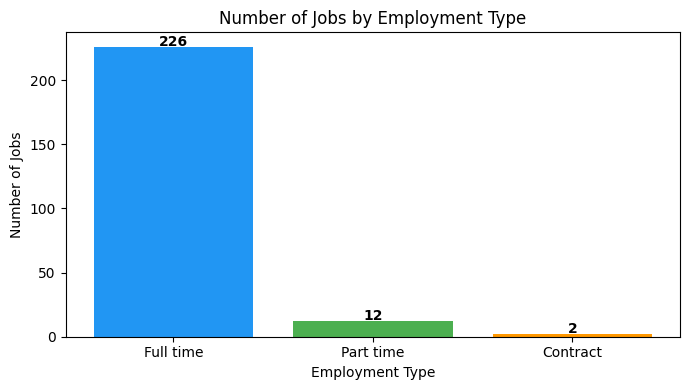

Plot 1 saved as plot1_job_types.png


In [273]:
# ── PLOT 1: Number of Jobs by Employment Type ─────────────────

counts = df['job_type'].value_counts()

plt.figure(figsize=(7, 4))
plt.bar(counts.index, counts.values, color=['#2196F3', '#4CAF50', '#FF9800'])
plt.title('Number of Jobs by Employment Type')
plt.xlabel('Employment Type')
plt.ylabel('Number of Jobs')

# Add the count number on top of each bar
for i, v in enumerate(counts.values):
    plt.text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('plot1_job_types.png', dpi=100)
plt.show()
print('Plot 1 saved as plot1_job_types.png')

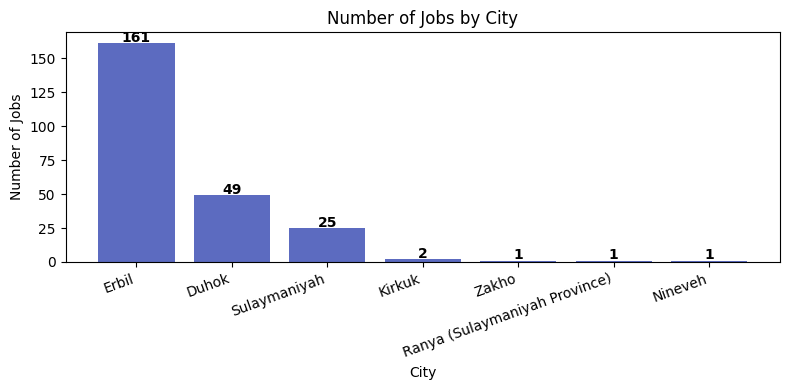

Plot 2 saved as plot2_locations.png


In [274]:
# ── PLOT 2: Number of Jobs by Location ───────────────────────

loc_counts = df['location'].value_counts()

plt.figure(figsize=(8, 4))
plt.bar(loc_counts.index, loc_counts.values, color='#5C6BC0')
plt.title('Number of Jobs by City')
plt.xlabel('City')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=20, ha='right')

# Add the count number on top of each bar
for i, v in enumerate(loc_counts.values):
    plt.text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('plot2_locations.png', dpi=100)
plt.show()
print('Plot 2 saved as plot2_locations.png')

In [275]:
# ── STEP 7: Split into Training and Testing sets ──────────────
#
# We create deadline_status here so it is ready for Section 3.3 and 3.5.
#   0 = Expired  (deadline already passed)
#   1 = Active   (deadline is today or in the future)
#
# We also do ONE train/test split that will be reused in Sections 3.3 and 3.5.
# This avoids repeating the same split code everywhere.

df['deadline_status'] = (df['days_until_deadline'] >= 0).astype(int)

# Features (same 4 columns used in all classification/NN sections)
X = df[['location_encoded', 'category_encoded', 'job_type_encoded', 'salary_disclosed']]
y = df['deadline_status']   # 0 = Expired, 1 = Active

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set : {len(X_train)} rows  (80%)')
print(f'Testing set  : {len(X_test)} rows  (20%)')
print(f'Target column: deadline_status  (0=Expired, 1=Active)')
print(f'  Expired in training: {(y_train==0).sum()}   Active: {(y_train==1).sum()}')

Training set : 192 rows  (80%)
Testing set  : 48 rows  (20%)
Target column: deadline_status  (0=Expired, 1=Active)
  Expired in training: 145   Active: 47


In [276]:
# ── Final: Save the cleaned dataset ──────────────────────────
# Save the cleaned version (with the new encoded columns) for use in later sections

df.to_csv('jobs_krd_clean.csv', index=False, encoding='utf-8-sig')

print('Cleaned dataset saved to jobs_krd_clean.csv')
print()
print('Final DataFrame columns:')
print(list(df.columns))
print()
print('Shape:', df.shape)
df.tail()

Cleaned dataset saved to jobs_krd_clean.csv

Final DataFrame columns:
['title', 'company', 'location', 'category', 'job_type', 'deadline', 'salary', 'url', 'salary_disclosed', 'days_until_deadline', 'job_type_encoded', 'location_encoded', 'category_encoded', 'deadline_status']

Shape: (240, 14)


,title,company,location,category,job_type,deadline,salary,url,salary_disclosed,days_until_deadline,job_type_encoded,location_encoded,category_encoded,deadline_status
235,Graphic Designer,Kano Printing Company,Duhok,Marketing,Full time,2026-03-10,Not disclosed,https://jobs.krd/explore-jobs/Graphic-Designer...,0,-68,1,0,15,0
236,Payments Processing Officer,VCG Markets,Erbil,Finance,Full time,2026-03-10,Not disclosed,https://jobs.krd/explore-jobs/Payments-Process...,0,-68,1,1,9,0
237,Human Recourses Manager,ALSALT Hospitality,Erbil,Unknown,Full time,2026-03-09,Not disclosed,https://jobs.krd/explore-jobs/Human-Recourses-...,0,-69,1,1,28,0
238,Salesperson (Female),MY LIMITED,Erbil,Sales,Part time,2026-03-31,Not disclosed,https://jobs.krd/explore-jobs/Salesperson-(Fem...,0,-47,2,1,21,0
239,Sales Representative (Male),Ramos Company,Duhok,Sales,Full time,2026-03-08,Not disclosed,https://jobs.krd/explore-jobs/Sales-Representa...,0,-70,1,0,21,0


---
## Section 3.2 — Regression

**Goal:** Predict how likely a job with a given title is to be posted in the Kurdistan job market.

We assign each job a **posting probability** based on how common its category is in the dataset (e.g. Marketing jobs appear most often — highest probability; niche roles appear rarely — lower probability).

We then train a **Ridge Regression** model that reads a job title and predicts that probability.

> *Example: "How likely is a Backend Developer position to be posted?"*

In [277]:
# Import the regression model, TF-IDF vectorizer, and error metrics
from sklearn.linear_model import Ridge
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print('Regression libraries loaded.')

Regression libraries loaded.


In [278]:
# ── STEP 1: Create the target — posting probability ───────────
#
# For each job we calculate how common its category is in the dataset.
# posting_probability = (number of jobs in that category) / (total jobs)
#
# For example:
#   Marketing has 53 jobs out of 240  →  22.1%
#   Engineering has 9 jobs out of 240 →  3.8%

category_counts = df['category'].value_counts()
df['posting_probability'] = df['category'].map(category_counts) / len(df)

y_reg = df['posting_probability']

print('Top 10 categories by posting probability:')
print()
for cat, count in category_counts.head(10).items():
    prob = count / len(df)
    print(f'  {cat[:35]:<35}  {count} jobs  ({prob:.1%})')
print()
print(f'Target range:  {y_reg.min():.4f}  to  {y_reg.max():.4f}')
print(f'Target mean :  {y_reg.mean():.4f}')

# ── STEP 2: Convert job titles to numbers using TF-IDF ─────────
#
# TF-IDF turns each job title into a row of numbers.
# ngram_range=(1,2) means we capture single words AND two-word phrases,
#   e.g. "marketing" and "marketing manager" are both features.
# max_features=100 keeps the 100 most useful terms.

tfidf = TfidfVectorizer(max_features=100, ngram_range=(1, 2))
X_reg = tfidf.fit_transform(df['title'])   # shape: 240 rows x 100 columns

print()
print(f'TF-IDF matrix shape: {X_reg.shape}   (jobs x vocabulary terms)')
print('Sample vocabulary terms:')
print(tfidf.get_feature_names_out()[:30])

Top 10 categories by posting probability:

  Marketing                            53 jobs  (22.1%)
  Sales                                36 jobs  (15.0%)
  Operations/Production                30 jobs  (12.5%)
  Unknown                              15 jobs  (6.2%)
  Human Resources                      13 jobs  (5.4%)
  Finance                              13 jobs  (5.4%)
  Education                            11 jobs  (4.6%)
  Facilities Management                9 jobs  (3.8%)
  Information Technology (IT)          9 jobs  (3.8%)
  Engineering                          9 jobs  (3.8%)

Target range:  0.0042  to  0.2208
Target mean :  0.1061

TF-IDF matrix shape: (240, 100)   (jobs x vocabulary terms)
Sample vocabulary terms:
['accountant' 'agent' 'analyst' 'assistant' 'brand' 'brand face'
 'business' 'chef' 'collection' 'collection for' 'consultant' 'content'
 'content creator' 'control' 'coordinator' 'creator' 'cuisine' 'cv'
 'cv collection' 'data' 'data analyst' 'designer' 'designer

In [279]:
# ── STEP 3: Split the data (80% train, 20% test) ──────────────

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f'Training rows: {len(y_train_r)}')
print(f'Testing rows:  {len(y_test_r)}')

Training rows: 192
Testing rows:  48


In [280]:
# ── STEP 4: Train the Ridge Regression model ──────────────────
#
# Ridge is Linear Regression with regularisation (alpha=0.1).
# Regularisation prevents the model from overfitting on the 100 TF-IDF features.
# It learns which title words/phrases link to high-frequency categories
# (e.g. 'marketing manager') vs low-frequency ones (e.g. 'backend developer').

model = Ridge(alpha=0.1)
model.fit(X_train_r, y_train_r)

print('Model trained successfully.')
print()

# Show the terms with the biggest impact on posting probability
coef_df = pd.DataFrame({
    'Term'       : tfidf.get_feature_names_out(),
    'Coefficient': model.coef_.round(4)
}).sort_values('Coefficient', ascending=False)

print('Top 5 terms that INCREASE posting probability:')
print(coef_df.head(5).to_string(index=False))
print()
print('Top 5 terms that DECREASE posting probability:')
print(coef_df.tail(5).to_string(index=False))

Model trained successfully.

Top 5 terms that INCREASE posting probability:
        Term  Coefficient
   marketing       0.1887
       brand       0.1660
videographer       0.1391
      editor       0.1374
    designer       0.1313

Top 5 terms that DECREASE posting probability:
               Term  Coefficient
electrical engineer      -0.0574
           engineer      -0.0717
           interior      -0.0734
  interior designer      -0.0734
     designer video      -0.1469


In [281]:
# ── STEP 5: Predict posting probability for new job titles ────
#
# We can now type any job title and the model will estimate
# how likely that kind of job is to be posted in Kurdistan.

def predict_prob(title):
    vec  = tfidf.transform([title])
    prob = model.predict(vec)[0]
    return max(0.0, min(1.0, prob))   # keep result between 0 and 1

# Try a few example job titles
example_titles = [
    'Backend Developer',
    'Marketing Manager',
    'Sales Representative',
    'Nurse',
    'Accountant',
    'Software Engineer',
    'Graphic Designer',
]

print('Job Title                          | Predicted Posting Probability')
print('-' * 58)
for title in example_titles:
    p = predict_prob(title)
    print(f'  {title:<33} | {p:.1%}')

# Show actual vs predicted on the test set
print()
y_pred_r = model.predict(X_test_r)
y_pred_r[y_pred_r < 0] = 0
y_pred_r[y_pred_r > 1] = 1

comparison = pd.DataFrame({
    'Actual probability'   : y_test_r.values[:8].round(3),
    'Predicted probability': y_pred_r[:8].round(3)
})
print('Sample - Actual vs Predicted (test set):')
print(comparison.to_string(index=False))

Job Title                          | Predicted Posting Probability
----------------------------------------------------------
  Backend Developer                 | 3.5%
  Marketing Manager                 | 22.0%
  Sales Representative              | 15.8%
  Nurse                             | 7.4%
  Accountant                        | 5.5%
  Software Engineer                 | 0.2%
  Graphic Designer                  | 17.8%

Sample - Actual vs Predicted (test set):
 Actual probability  Predicted probability
              0.150                  0.096
              0.004                  0.074
              0.038                  0.023
              0.046                  0.063
              0.125                  0.074
              0.004                  0.074
              0.221                  0.251
              0.221                  0.210


In [282]:
# ── STEP 6: Measure how well the model did ────────────────────
#
# MAE  — average error in probability (lower = better)
# RMSE — similar to MAE but penalises large errors more
# R²   — how much of the variance the model explains (1.0 = perfect)

mae  = mean_absolute_error(y_test_r, y_pred_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
r2   = r2_score(y_test_r, y_pred_r)

print('=== Model Performance ===')
print(f'MAE  (Mean Absolute Error) : {mae:.4f}  (avg error of {mae:.1%} in probability)')
print(f'RMSE (Root Mean Sq. Error) : {rmse:.4f}')
print(f'R²   (R-squared)           : {r2:.4f}')
print()
print('Interpretation:')
if r2 >= 0.5:
    print(f'  R² = {r2:.2f} — the model explains {r2:.0%} of the variance.')
    print('  Title words are a strong predictor of category posting frequency.')
elif r2 >= 0.1:
    print(f'  R² = {r2:.2f} — moderate fit.')
    print('  Title words carry real signal but many titles are ambiguous.')
else:
    print(f'  R² = {r2:.2f} — limited signal from title words alone.')
    print('  Job titles in this dataset are diverse; many words are unique.')
    print('  The model still gives a reasonable baseline estimate.')

=== Model Performance ===
MAE  (Mean Absolute Error) : 0.0304  (avg error of 3.0% in probability)
RMSE (Root Mean Sq. Error) : 0.0400
R²   (R-squared)           : 0.7207

Interpretation:
  R² = 0.72 — the model explains 72% of the variance.
  Title words are a strong predictor of category posting frequency.


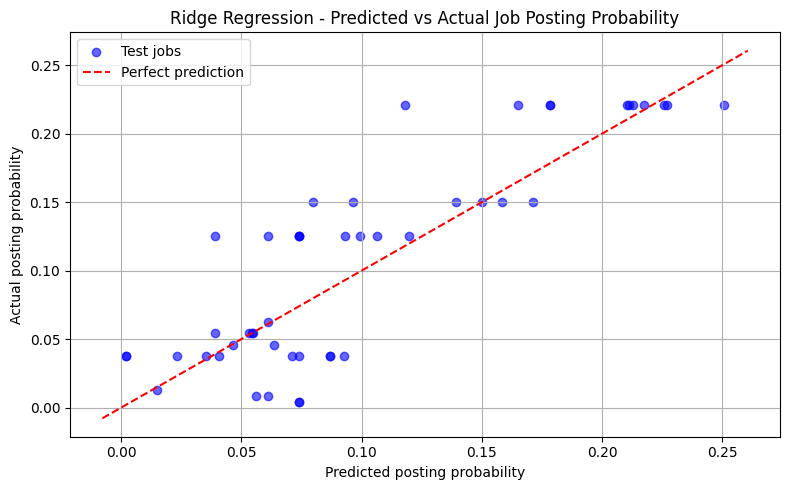

Plot 3 saved as plot3_regression.png


In [283]:
# ── PLOT 3: Actual vs Predicted Posting Probability ───────────
#
# Each blue dot = one job from the test set.
# Red dashed line = perfect prediction (where predicted == actual).
# Dots close to the red line mean the model predicted well.

plt.figure(figsize=(8, 5))

plt.scatter(y_pred_r, y_test_r, color='blue', alpha=0.6, label='Test jobs')

line_min = min(float(y_pred_r.min()), float(y_test_r.min())) - 0.01
line_max = max(float(y_pred_r.max()), float(y_test_r.max())) + 0.01
plt.plot([line_min, line_max], [line_min, line_max],
         color='red', linestyle='--', linewidth=1.5, label='Perfect prediction')

plt.xlabel('Predicted posting probability')
plt.ylabel('Actual posting probability')
plt.title('Ridge Regression - Predicted vs Actual Job Posting Probability')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('plot3_regression.png', dpi=100)
plt.show()
print('Plot 3 saved as plot3_regression.png')

---
## Section 3.3 — Classification

**Goal:** Take the same column (`days_until_deadline`) and split it into **two groups**, then train a classifier to predict which group each job belongs to.

| Group | Label | Meaning |
|-------|-------|---------|
| 0 | Expired | Deadline has already passed (days < 0) |
| 1 | Active | Deadline is today or in the future (days ≥ 0) |

We use a **Decision Tree** — one of the easiest classifiers to understand. It works like a flowchart of yes/no questions to make a decision.

In [284]:
# Import the Decision Tree classifier and classification metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

print('Classification libraries loaded.')

Classification libraries loaded.


In [285]:
# ── STEP 1: Check the two groups ─────────────────────────────
#
# deadline_status and the 80/20 split were already created in Section 3.1.
# We reuse them directly — no need to split again.

print('Group counts in the full dataset:')
print(df['deadline_status'].value_counts().rename({0: 'Expired (0)', 1: 'Active (1)'}))
print()
print(f'Expired jobs : {(df["deadline_status"] == 0).sum()}  ({(df["deadline_status"] == 0).mean():.0%})')
print(f'Active  jobs : {(df["deadline_status"] == 1).sum()}  ({(df["deadline_status"] == 1).mean():.0%})')
print()
print('Note: the data is imbalanced — 75% Expired vs 25% Active.')
print('This will make classification harder.')

Group counts in the full dataset:
deadline_status
Expired (0)    179
Active (1)      61
Name: count, dtype: int64

Expired jobs : 179  (75%)
Active  jobs : 61  (25%)

Note: the data is imbalanced — 75% Expired vs 25% Active.
This will make classification harder.


In [286]:
# ── STEP 2: Features and split — already ready from Section 3.1 ──
#
# X_train, X_test, y_train, y_test are defined in Section 3.1.
# We use them directly here.

print('Reusing the 80/20 split from Section 3.1:')
print(f'  Training rows : {len(X_train)}')
print(f'  Testing rows  : {len(X_test)}')
print(f'  Features used : {list(X_train.columns)}')

Reusing the 80/20 split from Section 3.1:
  Training rows : 192
  Testing rows  : 48
  Features used : ['location_encoded', 'category_encoded', 'job_type_encoded', 'salary_disclosed']


In [287]:
# ── STEP 3: Train the Decision Tree classifier ───────────────
#
# max_depth=3 keeps the tree simple so it does not memorise the
# training data (overfitting).
#
# class_weight='balanced' is important here because our data is
# imbalanced: 75% Expired vs 25% Active.
# Without this, the model just predicts "Expired" every single time,
# which gives 75% accuracy but is completely useless.
# 'balanced' forces the model to try to learn both classes.

clf = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

print('Decision Tree trained.')
print()
importance_df = pd.DataFrame({
    'Feature'   : X_train.columns,
    'Importance': clf.feature_importances_.round(3)
}).sort_values('Importance', ascending=False)
print('Feature Importances:')
print(importance_df.to_string(index=False))

Decision Tree trained.

Feature Importances:
         Feature  Importance
category_encoded       0.652
job_type_encoded       0.348
location_encoded       0.000
salary_disclosed       0.000


In [288]:
# ── STEP 4: Make predictions and measure accuracy ────────────

y_pred_c = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_c)

print(f'Accuracy: {accuracy:.2%}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_c,
                             target_names=['Expired', 'Active'],
                             zero_division=0))
print('─' * 50)
print('Why is accuracy lower than 75%?')
print('  A model that ALWAYS says "Expired" would score 75%.')
print('  That looks good but is useless — it never finds Active jobs.')
print('  class_weight=balanced makes the model try harder on Active jobs,')
print('  which lowers overall accuracy but makes the model more useful.')

Accuracy: 62.50%

Classification Report:
              precision    recall  f1-score   support

     Expired       0.69      0.85      0.76        34
      Active       0.17      0.07      0.10        14

    accuracy                           0.62        48
   macro avg       0.43      0.46      0.43        48
weighted avg       0.54      0.62      0.57        48

──────────────────────────────────────────────────
Why is accuracy lower than 75%?
  A model that ALWAYS says "Expired" would score 75%.
  That looks good but is useless — it never finds Active jobs.
  class_weight=balanced makes the model try harder on Active jobs,
  which lowers overall accuracy but makes the model more useful.


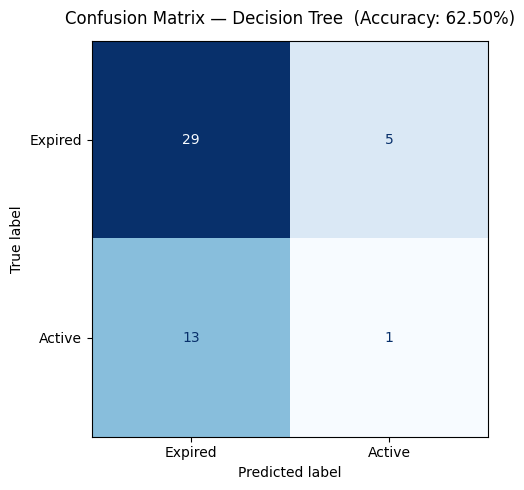

Plot 4 saved.


In [289]:
# ── PLOT 4: Confusion Matrix ──────────────────────────────────
#
# Rows  = what the job actually was
# Cols  = what the model predicted
#
# Top-left  (True Negative)  : said Expired, was Expired  ✓
# Top-right (False Positive) : said Active,  was Expired  ✗
# Bot-left  (False Negative) : said Expired, was Active   ✗
# Bot-right (True Positive)  : said Active,  was Active   ✓

cm = confusion_matrix(y_test, y_pred_c)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=['Expired', 'Active']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — Decision Tree  (Accuracy: {accuracy:.2%})', fontsize=12, pad=12)

plt.tight_layout()
plt.savefig('plot4_confusion_matrix.png', dpi=100)
plt.show()
print('Plot 4 saved.')

---
## Section 3.4 — Clustering

**Goal:** Use **K-Means** to automatically group jobs into clusters without telling it what the groups should be.

K-Means works by:
1. Placing k random centre points in the data
2. Assigning every row to its nearest centre
3. Moving each centre to the average of its group
4. Repeating steps 2–3 until nothing changes

We try several values of k and use the **Elbow Method** to pick the best one.

In [290]:
# Import K-Means and the scaler
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print('Clustering libraries loaded.')

Clustering libraries loaded.


In [291]:
# ── STEP 1: Prepare and scale the features ───────────────────
#
# K-Means uses distances between points.
# If one column has values 0–200 and another has 0–1,
# the big column will dominate the distance calculation unfairly.
# StandardScaler fixes this by making every column have
# mean = 0 and standard deviation = 1.

features = ['location_encoded', 'category_encoded',
            'job_type_encoded', 'salary_disclosed', 'days_until_deadline']

X_clust = df[features].copy()

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

print('Features used for clustering:', features)
print('Data scaled: mean ≈ 0, std ≈ 1 for every column.')

Features used for clustering: ['location_encoded', 'category_encoded', 'job_type_encoded', 'salary_disclosed', 'days_until_deadline']
Data scaled: mean ≈ 0, std ≈ 1 for every column.


In [292]:
# ── STEP 2: Elbow Method — try k = 2 to 6 ────────────────────
#
# For each value of k we record the "inertia":
# the total distance from every point to its cluster centre.
# Lower inertia = tighter clusters, but more clusters always helps.
# The "elbow" is where adding more clusters stops helping much.

inertias = []
k_values = range(2, 7)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    print(f'  k = {k}   inertia = {km.inertia_:.1f}')

print('\nLook for the "elbow" — where the inertia stops dropping sharply.')

  k = 2   inertia = 959.6
  k = 3   inertia = 738.8
  k = 4   inertia = 550.1
  k = 5   inertia = 417.8
  k = 6   inertia = 339.1

Look for the "elbow" — where the inertia stops dropping sharply.


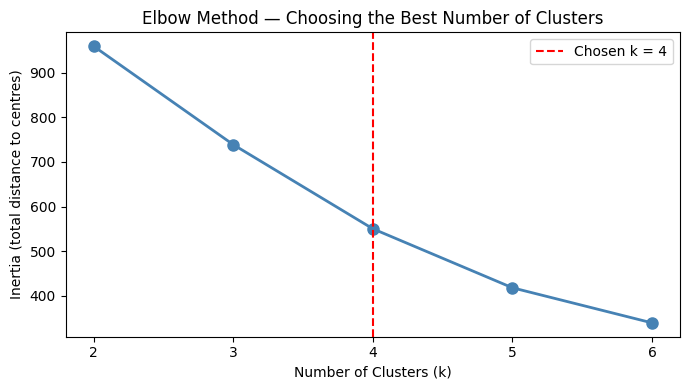

Plot 5 saved.  We choose k = 4 — the bend in the curve.
After k=4, adding more clusters gives smaller gains.


In [293]:
# ── PLOT 5: Elbow Curve ───────────────────────────────────────

plt.figure(figsize=(7, 4))
plt.plot(list(k_values), inertias, marker='o', color='steelblue', linewidth=2, markersize=8)

# Highlight the chosen k
chosen_k = 4
plt.axvline(x=chosen_k, color='red', linestyle='--', linewidth=1.5,
            label=f'Chosen k = {chosen_k}')

plt.title('Elbow Method — Choosing the Best Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (total distance to centres)')
plt.xticks(list(k_values))
plt.legend()
plt.tight_layout()
plt.savefig('plot5_elbow.png', dpi=100)
plt.show()
print(f'Plot 5 saved.  We choose k = {chosen_k} — the bend in the curve.')
print('After k=4, adding more clusters gives smaller gains.')

In [294]:
# ── STEP 3: Train the final K-Means with k = 4 ───────────────

km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_scaled)

print('Cluster sizes:')
for c in sorted(df['cluster'].unique()):
    print(f'  Cluster {c}: {(df["cluster"] == c).sum()} jobs')

Cluster sizes:
  Cluster 0: 189 jobs
  Cluster 1: 12 jobs
  Cluster 2: 13 jobs
  Cluster 3: 26 jobs


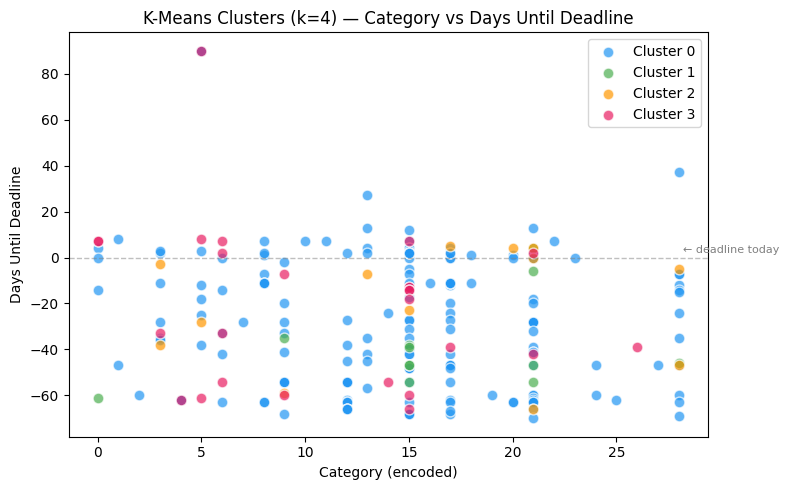

Plot 6 saved as plot6_clusters.png


In [295]:
# ── PLOT 6: Scatter Plot of Clusters ─────────────────────────
#
# We plot category_encoded (x-axis) vs days_until_deadline (y-axis).
# Each dot is one job, coloured by its cluster.

colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
labels = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

plt.figure(figsize=(8, 5))

for c in sorted(df['cluster'].unique()):
    subset = df[df['cluster'] == c]
    plt.scatter(subset['category_encoded'],
                subset['days_until_deadline'],
                color=colors[c], label=labels[c],
                alpha=0.7, edgecolors='white', s=60)

plt.title('K-Means Clusters (k=4) — Category vs Days Until Deadline')
plt.xlabel('Category (encoded)')
plt.ylabel('Days Until Deadline')
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
plt.text(28.2, 2, '← deadline today', fontsize=8, color='gray')
plt.legend()
plt.tight_layout()
plt.savefig('plot6_clusters.png', dpi=100)
plt.show()
print('Plot 6 saved as plot6_clusters.png')

In [296]:
# ── STEP 4: Describe each cluster ────────────────────────────
#
# For each cluster we show the most common values and averages
# so we can give it a meaningful name.

print('=' * 55)
print('  Cluster Profiles')
print('=' * 55)

cluster_names = {
    0: 'General Full-Time (Erbil)',
    1: 'Part-Time Jobs',
    2: 'Jobs With Disclosed Salary',
    3: 'Sulaymaniyah Full-Time'
}

for c in sorted(df['cluster'].unique()):
    sub = df[df['cluster'] == c]
    print(f'\nCluster {c} — "{cluster_names[c]}"  ({len(sub)} jobs)')
    print(f'  Most common location : {sub["location"].mode()[0]}')
    print(f'  Most common job type : {sub["job_type"].mode()[0]}')
    print(f'  Most common category : {sub["category"].mode()[0]}')
    print(f'  Salary disclosed     : {sub["salary_disclosed"].mean():.0%}')
    print(f'  Avg days to deadline : {sub["days_until_deadline"].mean():.0f} days')

print('\n' + '=' * 55)

  Cluster Profiles

Cluster 0 — "General Full-Time (Erbil)"  (189 jobs)
  Most common location : Erbil
  Most common job type : Full time
  Most common category : Marketing
  Salary disclosed     : 0%
  Avg days to deadline : -27 days

Cluster 1 — "Part-Time Jobs"  (12 jobs)
  Most common location : Erbil
  Most common job type : Part time
  Most common category : Marketing
  Salary disclosed     : 8%
  Avg days to deadline : -39 days

Cluster 2 — "Jobs With Disclosed Salary"  (13 jobs)
  Most common location : Erbil
  Most common job type : Full time
  Most common category : Sales
  Salary disclosed     : 100%
  Avg days to deadline : -20 days

Cluster 3 — "Sulaymaniyah Full-Time"  (26 jobs)
  Most common location : Sulaymaniyah
  Most common job type : Full time
  Most common category : Marketing
  Salary disclosed     : 0%
  Avg days to deadline : -21 days



---
## Section 3.5 — Neural Network

**Goal:** Build a Neural Network that does the same job as the Decision Tree from Section 3.3 — classify each job as **Expired** or **Active** — then compare the two models.

**How a Neural Network works:**
- Data enters an **input layer** (one node per feature)
- It passes through **hidden layers** where the network learns patterns
- It exits through an **output layer** that gives the final prediction
- During training, the network adjusts its internal weights to reduce the **loss** (error)

Our network has this shape: `4 inputs → 16 nodes → 8 nodes → 1 output`

In [297]:
# Import the Neural Network classifier from sklearn
from sklearn.neural_network import MLPClassifier   # MLP = Multi-Layer Perceptron
import warnings
warnings.filterwarnings('ignore')   # hide convergence warnings for clean output

print('Neural network library loaded.')

Neural network library loaded.


In [298]:
# ── STEP 1: Scale the features ───────────────────────────────
#
# We reuse the same X_train, X_test, y_train, y_test from Section 3.1.
# Neural networks need scaled input — we apply StandardScaler here.
# Important: fit the scaler ONLY on training data, then apply to both.

nn_scaler      = StandardScaler()
X_train_scaled = nn_scaler.fit_transform(X_train)
X_test_scaled  = nn_scaler.transform(X_test)   # same scaler, do NOT refit

print('Features scaled for the neural network.')
print(f'Training rows : {len(X_train_scaled)}')
print(f'Testing rows  : {len(X_test_scaled)}')

Features scaled for the neural network.
Training rows : 192
Testing rows  : 48


In [299]:
# ── STEP 2: Build and train the Neural Network ───────────────
#
# hidden_layer_sizes=(16, 8) means:
#   - First hidden layer  : 16 neurons
#   - Second hidden layer :  8 neurons
#
# solver='adam'  — the most popular optimizer (adjusts weights smartly)
# max_iter=1000  — maximum number of training passes through the data
# learning_rate_init=0.01 — how big each weight update step is

nn_model = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    solver='adam',
    max_iter=1000,
    learning_rate_init=0.01,
    random_state=42
)

nn_model.fit(X_train_scaled, y_train)

print(f'Training finished after {nn_model.n_iter_} iterations.')
print(f'Final training loss : {nn_model.loss_curve_[-1]:.4f}')

Training finished after 362 iterations.
Final training loss : 0.4195


In [300]:
# ── STEP 3: Make predictions and evaluate ────────────────────

y_pred_nn = nn_model.predict(X_test_scaled)
nn_accuracy = accuracy_score(y_test, y_pred_nn)

print(f'Neural Network Accuracy: {nn_accuracy:.2%}\n')
print('Classification Report:')
print(classification_report(y_test, y_pred_nn,
                             target_names=['Expired', 'Active'],
                             zero_division=0))

Neural Network Accuracy: 70.83%

Classification Report:
              precision    recall  f1-score   support

     Expired       0.73      0.94      0.82        34
      Active       0.50      0.14      0.22        14

    accuracy                           0.71        48
   macro avg       0.61      0.54      0.52        48
weighted avg       0.66      0.71      0.65        48



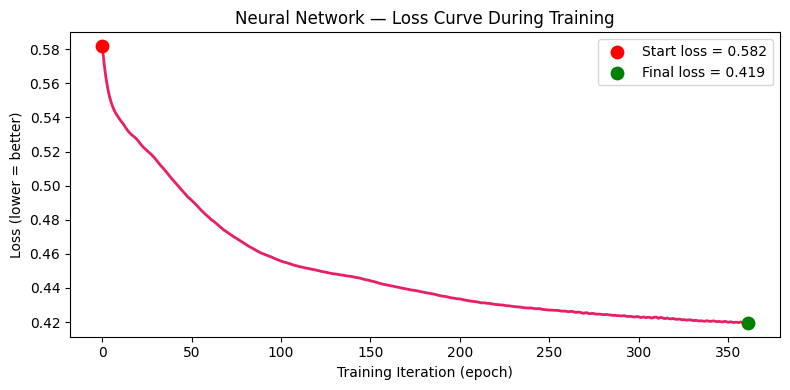

Plot 7 saved as plot7_loss_curve.png


In [301]:
# ── PLOT 7: Loss Curve — how the error changed during training ─
#
# Each point on the curve = one full pass through the training data.
# The loss should go DOWN over time as the model learns.
# When the curve flattens, the model has stopped improving.

plt.figure(figsize=(8, 4))
plt.plot(nn_model.loss_curve_, color='#E91E63', linewidth=2)

plt.title('Neural Network — Loss Curve During Training')
plt.xlabel('Training Iteration (epoch)')
plt.ylabel('Loss (lower = better)')

# Mark the start and end loss
plt.scatter([0], [nn_model.loss_curve_[0]], color='red', zorder=5, s=80,
            label=f'Start loss = {nn_model.loss_curve_[0]:.3f}')
plt.scatter([len(nn_model.loss_curve_)-1], [nn_model.loss_curve_[-1]],
            color='green', zorder=5, s=80,
            label=f'Final loss = {nn_model.loss_curve_[-1]:.3f}')

plt.legend()
plt.tight_layout()
plt.savefig('plot7_loss_curve.png', dpi=100)
plt.show()
print('Plot 7 saved as plot7_loss_curve.png')

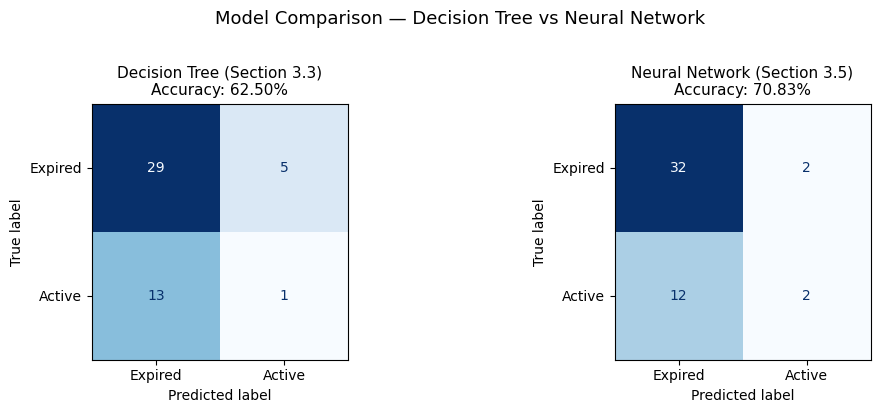

Plot 8 saved.

  Final Comparison
  Decision Tree  accuracy : 62.50%
  Neural Network accuracy : 70.83%

  Active jobs correctly found:
    Decision Tree  : 1 out of 14
    Neural Network : 2 out of 14

  The Neural Network finds more Active jobs.
  Both models struggle because Active jobs are only 25% of the data.


In [302]:
# ── PLOT 8: Side-by-side Confusion Matrices — NN vs Decision Tree ──
#
# clf       = the Decision Tree trained in Section 3.3
# nn_model  = the Neural Network trained above
# Both use the SAME X_test and y_test from Section 3.1 — fair comparison.

dt_accuracy = accuracy_score(y_test, y_pred_c)   # y_pred_c from Section 3.3

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, y_pred, title in [
    (axes[0], y_pred_c,
     f'Decision Tree (Section 3.3)\nAccuracy: {dt_accuracy:.2%}'),
    (axes[1], y_pred_nn,
     f'Neural Network (Section 3.5)\nAccuracy: {nn_accuracy:.2%}'),
]:
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                           display_labels=['Expired', 'Active']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title, fontsize=11)

plt.suptitle('Model Comparison — Decision Tree vs Neural Network', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plot8_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print('Plot 8 saved.')

# Summary table
nn_cm = confusion_matrix(y_test, y_pred_nn)
dt_cm = confusion_matrix(y_test, y_pred_c)
print()
print('=' * 42)
print('  Final Comparison')
print('=' * 42)
print(f'  Decision Tree  accuracy : {dt_accuracy:.2%}')
print(f'  Neural Network accuracy : {nn_accuracy:.2%}')
print()
print(f'  Active jobs correctly found:')
print(f'    Decision Tree  : {dt_cm[1,1]} out of {dt_cm[1,:].sum()}')
print(f'    Neural Network : {nn_cm[1,1]} out of {nn_cm[1,:].sum()}')
print()
print('  The Neural Network finds more Active jobs.')
print('  Both models struggle because Active jobs are only 25% of the data.')